# 07_05: Simulating data

In [1]:
import math
import collections
import dataclasses
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp

In [2]:
import random
import faker

In [3]:
fake = faker.Faker()

In [4]:
fake.name()

'Kara Rodriguez'

In [5]:
fake.address()

'USS Crane\nFPO AE 52347'

In [6]:
fake.date_of_birth()

datetime.date(1983, 7, 20)

In [7]:
fake.city()

'Cynthiafurt'

In [8]:
fake.state_abbr()

'DC'

In [9]:
music_genres = ['Rock', 'Pop', 'Jazz', 'Hip Hop', 'Country', 'Electronic', 'Blues', 
                'Reggae', 'Metal', 'Folk', 'Soul', 'R&B', 'Punk', 'Indie', 'Alternative']

In [10]:
def artist():
    return {'name': fake.name(),
            'dob': pd.to_datetime(fake.date_of_birth(minimum_age=16, maximum_age=80)), # from Python to pandas date object
            'birthplace': f'{fake.city()} {fake.state_abbr()}',
            'genre': fake.random_element(music_genres)}

In [11]:
artist()

{'name': 'Jesus Hamilton',
 'dob': Timestamp('2001-10-16 00:00:00'),
 'birthplace': 'Audreyberg DE',
 'genre': 'Jazz'}

In [12]:
artists = pd.DataFrame([artist() for i in range(100)])
artists.index.name = 'artist_id'

In [13]:
artists

,name,dob,birthplace,genre
artist_id,,,,
0,Edward Allen,1945-06-21,Shieldsberg MI,Country
1,Patricia Chen,2005-01-06,West David NH,Blues
2,Amy Mullen,1955-01-03,Marymouth HI,Blues
3,Andrew Perez,1972-04-13,South Arthur RI,Reggae
4,Jeffrey Young,1994-06-20,Danielleview VA,Alternative
...,...,...,...,...
95,Mrs. Christine Torres DDS,1968-10-24,Hallshire DE,Country
96,Mr. Joseph White,1996-03-09,Jeffshire MN,Metal
97,Mrs. Heather Nichols,1980-10-16,Adamsfurt AZ,Folk


In [14]:
def song():
    artist = fake.random_element(artists.index)
    
    return {'title': fake.text(max_nb_chars=20)[:-1], # skip the final period
            'release': pd.to_datetime(fake.past_date(start_date="-2y")), # get dates in the last two years
            'artist_id': artist,
            'genre': artists.loc[artist, 'genre']}

In [15]:
song()

{'title': 'Age want especially',
 'release': Timestamp('2025-05-01 00:00:00'),
 'artist_id': 67,
 'genre': 'Soul'}

In [16]:
song()

{'title': 'Then note skin',
 'release': Timestamp('2024-04-27 00:00:00'),
 'artist_id': 24,
 'genre': 'Electronic'}

In [17]:
songs = pd.DataFrame([song() for i in range(500)])
songs.index.name = 'song_id'

In [18]:
songs

,title,release,artist_id,genre
song_id,,,,
0,Property tend,2025-03-06,3,Reggae
1,Mr whole positive,2025-12-21,78,Blues
2,Available shake,2025-01-09,80,Blues
3,Through water level,2025-12-19,88,Indie
4,Value hold fine,2025-01-21,83,Metal
...,...,...,...,...
495,Plant factor both,2026-03-01,81,Rock
496,Move college radio,2026-02-21,17,Pop
497,Turn rock prove,2026-02-11,92,Punk


In [19]:
songs.loc[0].release

Timestamp('2025-03-06 00:00:00')

In [20]:
duration = np.random.randint(10, 50)

In [21]:
songs.loc[0].release + pd.Timedelta(weeks=duration)

Timestamp('2025-06-05 00:00:00')

In [22]:
t = pd.date_range(start=songs.loc[0].release,
                  end=songs.loc[0].release + pd.Timedelta(weeks=duration),
                  freq='W-MON')[:duration] # handle case where release is on Monday
t

DatetimeIndex(['2025-03-10', '2025-03-17', '2025-03-24', '2025-03-31',
               '2025-04-07', '2025-04-14', '2025-04-21', '2025-04-28',
               '2025-05-05', '2025-05-12', '2025-05-19', '2025-05-26',
               '2025-06-02'],
              dtype='datetime64[us]', freq='W-MON')

In [23]:
initial_plays = np.random.randint(500000, 1000000)

In [24]:
cleanplays = initial_plays * np.linspace(1, 1/duration, duration)

In [25]:
noisyplays = cleanplays * np.random.uniform(0.8, 1.2, duration)

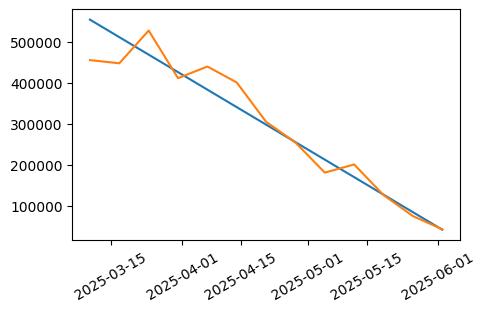

In [26]:
pp.figure(figsize=(5,3))
pp.plot(t, cleanplays)
pp.plot(t, noisyplays)
pp.xticks(rotation=30); # angled tick labels are more readable

In [27]:
def history(song_id):
    duration = np.random.randint(10, 50)

    t = pd.date_range(start=songs.loc[song_id].release,
                      end=songs.loc[song_id].release + pd.Timedelta(weeks=duration),
                      freq='W-MON')[:duration]

    initial_plays = np.random.randint(500000, 1000000)
    plays = initial_plays * np.linspace(1, 0, duration) * np.random.uniform(0.8, 1.2, duration)
    
    return pd.DataFrame({'song_id': song_id, 'plays': plays.astype(int), 'date': t})

In [28]:
history(1).head()

,song_id,plays,date
0,1,802771,2025-12-22
1,1,794965,2025-12-29
2,1,715707,2026-01-05
3,1,795723,2026-01-12
4,1,665482,2026-01-19


In [29]:
histories = pd.concat([history(song_id) for song_id in songs.index], axis=0) \
              .reset_index().rename(columns={'index': 'week'})

In [30]:
histories

,week,song_id,plays,date
0,0,0,894267,2025-03-10
1,1,0,815501,2025-03-17
2,2,0,739814,2025-03-24
3,3,0,858668,2025-03-31
4,4,0,750380,2025-04-07
...,...,...,...,...
14501,12,499,174686,2025-06-09
14502,13,499,157447,2025-06-16
14503,14,499,93984,2025-06-23
14504,15,499,56620,2025-06-30


In [31]:
histories = histories[(histories.date > pd.Timestamp.today() - pd.Timedelta(weeks=52)) &
                      (histories.date <= pd.Timestamp.today())]

In [32]:
histories = histories.sort_values(['date', 'plays'], ascending=[True, False])

In [33]:
topten = histories.groupby('date').head(10).set_index('date')
topten

,week,song_id,plays
date,,,
2025-03-10,0,480,1155167
2025-03-10,2,404,929687
2025-03-10,4,465,899162
2025-03-10,0,0,894267
2025-03-10,5,423,892490
...,...,...,...
2026-03-02,1,293,877601
2026-03-02,3,232,872713
2026-03-02,3,453,837474


In [36]:
topten.loc['2025-03-10']

,week,song_id,plays
date,,,
2025-03-10,0,480,1155167
2025-03-10,2,404,929687
2025-03-10,4,465,899162
2025-03-10,0,0,894267
2025-03-10,5,423,892490
2025-03-10,2,243,888039
2025-03-10,5,433,846977
2025-03-10,0,26,835248
2025-03-10,5,108,826689


In [37]:
topten['rank'] = topten.groupby('date').plays.rank(ascending=False)

In [38]:
topten

,week,song_id,plays,rank
date,,,,
2025-03-10,0,480,1155167,1.0
2025-03-10,2,404,929687,2.0
2025-03-10,4,465,899162,3.0
2025-03-10,0,0,894267,4.0
2025-03-10,5,423,892490,5.0
...,...,...,...,...
2026-03-02,1,293,877601,6.0
2026-03-02,3,232,872713,7.0
2026-03-02,3,453,837474,8.0


In [39]:
songs.head()

,title,release,artist_id,genre
song_id,,,,
0,Property tend,2025-03-06,3,Reggae
1,Mr whole positive,2025-12-21,78,Blues
2,Available shake,2025-01-09,80,Blues
3,Through water level,2025-12-19,88,Indie
4,Value hold fine,2025-01-21,83,Metal


In [40]:
artists.head()

,name,dob,birthplace,genre
artist_id,,,,
0,Edward Allen,1945-06-21,Shieldsberg MI,Country
1,Patricia Chen,2005-01-06,West David NH,Blues
2,Amy Mullen,1955-01-03,Marymouth HI,Blues
3,Andrew Perez,1972-04-13,South Arthur RI,Reggae
4,Jeffrey Young,1994-06-20,Danielleview VA,Alternative


In [41]:
merged = topten.merge(songs, left_on='song_id', right_index=True) \
               .merge(artists.name, left_on='artist_id', right_index=True)
merged

,week,song_id,plays,rank,title,release,artist_id,genre,name
date,,,,,,,,,
2025-03-10,0,480,1155167,1.0,Religious should,2025-03-07,60,Reggae,Jeffrey Lucas
2025-03-10,2,404,929687,2.0,White us name,2025-02-18,27,R&B,Ronald Buckley
2025-03-10,4,465,899162,3.0,Let senior part,2025-02-08,6,Hip Hop,Tara Johnson
2025-03-10,0,0,894267,4.0,Property tend,2025-03-06,3,Reggae,Andrew Perez
2025-03-10,5,423,892490,5.0,Become walk baby,2025-02-01,99,Folk,George Roy
...,...,...,...,...,...,...,...,...,...
2026-03-02,1,293,877601,6.0,Simply PM,2026-02-18,94,Hip Hop,Megan Mckenzie
2026-03-02,3,232,872713,7.0,Cell never,2026-02-07,69,Soul,Albert Ball
2026-03-02,3,453,837474,8.0,Budget continue,2026-02-04,44,Metal,Vanessa Hampton


In [42]:
first = merged.query('rank == 1').groupby('name').title.count().sort_values(ascending=False).head()
first

name
Kristin Compton     5
Brett Harrison      4
Lauren Singh        3
Matthew Wright      3
Michelle Sanders    3
Name: title, dtype: int64

In [43]:
merged[(merged['rank'] == 1) & (merged['name'] == first.index[0])]

,week,song_id,plays,rank,title,release,artist_id,genre,name
date,,,,,,,,,
2025-05-05,1,251,1124049,1.0,Another recent,2025-04-24,49,Electronic,Kristin Compton
2025-05-12,2,251,1092600,1.0,Another recent,2025-04-24,49,Electronic,Kristin Compton
2025-06-09,6,251,960988,1.0,Another recent,2025-04-24,49,Electronic,Kristin Compton
2025-06-23,8,251,822132,1.0,Another recent,2025-04-24,49,Electronic,Kristin Compton
2025-07-07,10,251,884290,1.0,Another recent,2025-04-24,49,Electronic,Kristin Compton


In [44]:
merged.to_hdf('songtables.h5', key='topten')
artists.to_hdf('songtables.h5', key='artists')
songs.to_hdf('songtables.h5', key='songs')

In [45]:
h5 = pd.HDFStore('songtables.h5')

In [46]:
h5.keys()

['/artists', '/songs', '/topten']

In [47]:
h5['/artists']

,name,dob,birthplace,genre
artist_id,,,,
0,Edward Allen,1945-06-21,Shieldsberg MI,Country
1,Patricia Chen,2005-01-06,West David NH,Blues
2,Amy Mullen,1955-01-03,Marymouth HI,Blues
3,Andrew Perez,1972-04-13,South Arthur RI,Reggae
4,Jeffrey Young,1994-06-20,Danielleview VA,Alternative
...,...,...,...,...
95,Mrs. Christine Torres DDS,1968-10-24,Hallshire DE,Country
96,Mr. Joseph White,1996-03-09,Jeffshire MN,Metal
97,Mrs. Heather Nichols,1980-10-16,Adamsfurt AZ,Folk
